# 07.1 — Generalization Risk & Robustness Check

Esta análise curta mede concentração e fragilidade da regra experimental `jurisprudencia_geral` do Notebook 07. Ela não altera o detector V1, não cria V2 e não é um holdout: todo o corpus já informou o desenvolvimento.

## 1. Dataset, baseline congelada e avaliador

A V1 vem exclusivamente do pacote de produção. O avaliador preserva IoU >= 0,5, matching guloso um-para-um por documento e desempate determinístico.

In [1]:
from __future__ import annotations

import hashlib
import itertools
import re
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from bracis_jusbrasil.citations import CitationDetector

pd.set_option('display.max_colwidth', 120)
DATASET_DIR = next(path for path in (Path('material_desafio_jusbrasil_bracis'), Path('../material_desafio_jusbrasil_bracis')) if path.is_dir())
TEXT_DIR, GOLDENSET_PATH, DB_PATH = DATASET_DIR / 'txt', DATASET_DIR / 'goldenset.xlsx', DATASET_DIR / 'desafio1_bracis.db'

def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open('rb') as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b''):
            digest.update(chunk)
    return digest.hexdigest()

db_sha_before = sha256_file(DB_PATH)
gold = pd.read_excel(GOLDENSET_PATH, sheet_name='goldenset', engine='openpyxl').reset_index(names='gold_idx')
gold['nivel'] = 'N' + gold['nivel'].astype(str).str.removeprefix('N')
gold['inicio'], gold['fim'] = gold['inicio'].astype(int), gold['fim'].astype(int)
texts = {path.stem: path.read_text(encoding='utf-8') for path in sorted(TEXT_DIR.glob('*.txt'))}
gold['document_text'] = gold['documento_id'].map(texts)
gold['span_text'] = gold.apply(lambda row: row.document_text[row.inicio:row.fim], axis=1)
gold['trecho_esperado'] = gold['trecho'].astype(str).str.replace(r'\n', '\n', regex=False)
assert len(texts) == 26 and len(gold) == 225 and gold['span_text'].eq(gold['trecho_esperado']).all()
assert gold['nivel'].value_counts().to_dict() == {'N1': 116, 'N2': 109}

RULE_TYPES = {'cnj': 'jurisprudencia', 'processo_ou_recurso': 'jurisprudencia', 'sumula_numerada': 'jurisprudencia', 'lei_com_diploma': 'lei', 'dispositivo_legal': 'lei', 'tribunal_contextual': 'jurisprudencia'}

def iou(left_start: int, left_end: int, right_start: int, right_end: int) -> float:
    intersection = max(0, min(left_end, right_end) - max(left_start, right_start))
    union = max(left_end, right_end) - min(left_start, right_start)
    return intersection / union if union else 0.0

def production_records() -> list[dict]:
    detector = CitationDetector()
    return [{'documento_id': doc, 'start': item.start, 'end': item.end, 'text': item.text, 'rule': item.rule, 'tipo': RULE_TYPES[item.rule]} for doc, text in texts.items() for item in detector.detect(text)]

def deduplicate(records: list[dict]) -> pd.DataFrame:
    kept = {}
    for item in sorted(records, key=lambda row: (row['documento_id'], row['start'], row['end'], row['rule'])):
        kept.setdefault((item['documento_id'], item['start'], item['end']), item)
    frame = pd.DataFrame(kept.values()).reset_index(names='pred_idx')
    frame['nivel'] = frame['documento_id'].map(gold.drop_duplicates('documento_id').set_index('documento_id')['nivel'])
    return frame

def match_predictions(predictions: pd.DataFrame) -> pd.DataFrame:
    pairs = []
    for doc, gold_group in gold.groupby('documento_id'):
        for item in gold_group.itertuples():
            for candidate in predictions.loc[predictions.documento_id.eq(doc)].itertuples():
                value = iou(item.inicio, item.fim, candidate.start, candidate.end)
                if value >= .5: pairs.append({'gold_idx': item.gold_idx, 'pred_idx': candidate.pred_idx, 'iou': value, 'exact': item.inicio == candidate.start and item.fim == candidate.end})
    used_gold, used_pred, selected = set(), set(), []
    for pair in sorted(pairs, key=lambda row: (-row['iou'], row['gold_idx'], row['pred_idx'])):
        if pair['gold_idx'] not in used_gold and pair['pred_idx'] not in used_pred:
            selected.append(pair); used_gold.add(pair['gold_idx']); used_pred.add(pair['pred_idx'])
    return pd.DataFrame(selected, columns=['gold_idx', 'pred_idx', 'iou', 'exact'])

def metrics(name: str, predictions: pd.DataFrame, matches: pd.DataFrame, gold_subset: pd.DataFrame = gold, pred_subset: pd.DataFrame | None = None) -> dict:
    pred_subset = predictions if pred_subset is None else pred_subset
    selected = matches.loc[matches.gold_idx.isin(gold_subset.gold_idx) & matches.pred_idx.isin(pred_subset.pred_idx)]
    tp, fp, fn = len(selected), len(pred_subset) - selected.pred_idx.nunique(), len(gold_subset) - selected.gold_idx.nunique()
    precision, recall = (tp/(tp+fp) if tp+fp else 0), (tp/(tp+fn) if tp+fn else 0)
    return {'variant': name, 'TP': tp, 'FP': fp, 'FN': fn, 'precision': precision, 'recall': recall, 'F1': 2*precision*recall/(precision+recall) if precision+recall else 0, 'exact': int(selected.exact.sum())}

v1 = deduplicate(production_records())
v1_matches = match_predictions(v1)
baseline = metrics('V1', v1, v1_matches)
assert (len(v1), baseline['TP'], baseline['FP'], baseline['FN'], baseline['exact']) == (194, 105, 89, 120, 19)
print('SHA-256 antes:', db_sha_before)
display(pd.DataFrame([baseline]).round(3))


SHA-256 antes: d759681be82ee00f383b49a5c76c42dd475564e042272e00730252468dcb6e71


,variant,TP,FP,FN,precision,recall,F1,exact
0,V1,105,89,120,0.541,0.467,0.501,19


## 2. Regra experimental congelada

Os cinco branches abaixo decompõem exatamente a alternativa lexical `jurisprudencia_geral` avaliada no Notebook 07. Eles são usados apenas para atribuir o disparo e testar remoções; nenhuma expressão é adicionada nesta análise.

In [2]:
BRANCHES = {
    'jurisprudencia_estavel': re.compile(r'\bjurisprudência\s+(?:pacífica|consolidada)(?:\s+(?:desta|dos)\s+(?:Corte|tribunais superiores))?\b', re.I),
    'orientacao_jurisprudencial': re.compile(r'\borientação jurisprudencial(?:\s+consolidada)?\b', re.I),
    'entendimento_sumulado': re.compile(r'\bentendimento sumulado(?:\s+sobre\s+a\s+matéria)?\b', re.I),
    'precedentes_desta_casa': re.compile(r'\bprecedentes desta Casa(?:\s+em\s+20\d{2})?\b', re.I),
    'verbete_sumular_aplicavel': re.compile(r'\bverbete sumular aplicável\b', re.I),
}

def experimental_records(branches: tuple[str, ...] = tuple(BRANCHES)) -> list[dict]:
    records = production_records()
    for branch in branches:
        for doc, text in texts.items():
            for match in BRANCHES[branch].finditer(text):
                records.append({'documento_id': doc, 'start': match.start(), 'end': match.end(), 'text': match.group(0), 'rule': f'jurisprudencia_geral:{branch}', 'tipo': 'jurisprudencia'})
    return records

def evaluate(branches: tuple[str, ...] = tuple(BRANCHES), name: str = 'jurisprudencia_geral'):
    predictions = deduplicate(experimental_records(branches))
    matches = match_predictions(predictions)
    return predictions, matches, metrics(name, predictions, matches)

candidate, candidate_matches, candidate_metrics = evaluate()
assert (candidate_metrics['TP'], candidate_metrics['FP'], candidate_metrics['FN'], candidate_metrics['exact']) == (117, 89, 108, 25)
display(pd.DataFrame([baseline, candidate_metrics]).round(3))


,variant,TP,FP,FN,precision,recall,F1,exact
0,V1,105,89,120,0.541,0.467,0.501,19
1,jurisprudencia_geral,117,89,108,0.568,0.520,0.543,25


## 3. Os 12 ganhos: documentos, níveis, branches e contexto

A classificação do gold é exibida somente para inspeção posterior; ela não participa da regra, do matching ou de qualquer seleção.

,documento_id,nivel,inicio,fim,span_text,classificacao,branch,rule,exact_or_iou,context
0,gen_n1_003,N1,1041,1076,jurisprudência pacífica desta Corte,incompleta,jurisprudencia_estavel,jurisprudencia_geral:jurisprudencia_estavel,exact,"nto. Não se trata, aqui, de revolver matéria fática. Reforça o argumento ↵ a <GOLD> jurisprudência pacífica desta C..."
1,gen_n1_003,N1,2106,2143,entendimento sumulado sobre a matéria,incompleta,entendimento_sumulado,jurisprudencia_geral:entendimento_sumulado,exact,vamente. A questão de fundo ↵ comporta solução singela. Ampara a pretensão o <GOLD> entendimento sumulado sobre a m...
2,gen_n1_005,N1,534,569,jurisprudência\npacífica desta Corte,incompleta,jurisprudencia_estavel,jurisprudencia_geral:jurisprudencia_estavel,exact,"e rigor, portanto, o acolhimento da tese ora sustentada. Merece registro a <GOLD> jurisprudência ↵ pacífica desta C..."
11,gen_n1_005,N1,689,733,precedentes desta Casa em situações análogas,incompleta,precedentes_desta_casa,jurisprudencia_geral:precedentes_desta_casa,IoU=0.500,"vançar, convém delimitar o ↵ objeto da irresignação. A propósito, veja-se os <GOLD> precedentes desta Casa em situa..."
9,gen_n1_008,N1,702,746,orientação jurisprudencial da Corte Superior,incompleta,orientacao_jurisprudencial,jurisprudencia_geral:orientacao_jurisprudencial,IoU=0.591,"da acompanha, sem divergência ↵ relevante, esse entendimento. Vale invocar a <GOLD> orientação jurisprudencial da C..."
6,gen_n1_008,N1,2427,2462,verbete sumular aplicável à espécie,incompleta,verbete_sumular_aplicavel,jurisprudencia_geral:verbete_sumular_aplicavel,IoU=0.714,"efeito, a controvérsia posta nos autos não é nova. A propósito, ↵ veja-se o <GOLD> verbete sumular aplicável à esp..."
10,gen_n1_008,N1,2952,2996,orientação jurisprudencial da Corte Superior,incompleta,orientacao_jurisprudencial,jurisprudencia_geral:orientacao_jurisprudencial,IoU=0.591,eada na origem é suficiente para o deslinde da causa. ↵ Ampara a pretensão a <GOLD> orientação jurisprudencial da C...
3,gen_n1_010,N1,1124,1159,jurisprudência\npacífica desta Corte,incompleta,jurisprudencia_estavel,jurisprudencia_geral:jurisprudencia_estavel,exact,"igor, portanto, o acolhimento da tese ora sustentada. Ampara a pretensão a <GOLD> jurisprudência ↵ pacífica desta C..."
4,gen_n2_003,N2,2009,2060,jurisprudência\nconsolidada dos tribunais superiores,incompleta,jurisprudencia_estavel,jurisprudencia_geral:jurisprudencia_estavel,exact,subsistc fundamento autônomo ã amparar a pretensão. Reforça o argumento a <GOLD> jurisprudência ↵ consolidada dos ...
7,gen_n2_007,N2,2896,2931,verbete sumular aplicável à espécie,incompleta,verbete_sumular_aplicavel,jurisprudencia_geral:verbete_sumular_aplicavel,IoU=0.714,"ria. Com efeito, a controvérsia posta nos autos ↵ não é nova. Vale invocar o <GOLD> verbete sumular aplicável à esp..."


,documento_id,nivel,novos_TP,%_dos_12
2,gen_n1_008,N1,3,0.250000
0,gen_n1_003,N1,2,0.166667
1,gen_n1_005,N1,2,0.166667
3,gen_n1_010,N1,1,0.083333
4,gen_n2_003,N2,1,0.083333
5,gen_n2_007,N2,1,0.083333
6,gen_n2_012,N2,1,0.083333
7,gen_n2_013,N2,1,0.083333


,branch,TP_recuperados,documentos,N1,N2
1,jurisprudencia_estavel,4,4,3,1
4,verbete_sumular_aplicavel,3,3,1,2
0,entendimento_sumulado,2,2,1,1
2,orientacao_jurisprudencial,2,1,2,0
3,precedentes_desta_casa,1,1,1,0


,branch,superficie,quantidade,documentos
2,jurisprudencia_estavel,jurisprudência pacífica desta corte,3,3
5,verbete_sumular_aplicavel,verbete sumular aplicável,3,3
0,entendimento_sumulado,entendimento sumulado sobre a matéria,2,2
3,orientacao_jurisprudencial,orientação jurisprudencial,2,1
1,jurisprudencia_estavel,jurisprudência consolidada dos tribunais superiores,1,1
4,precedentes_desta_casa,precedentes desta casa,1,1


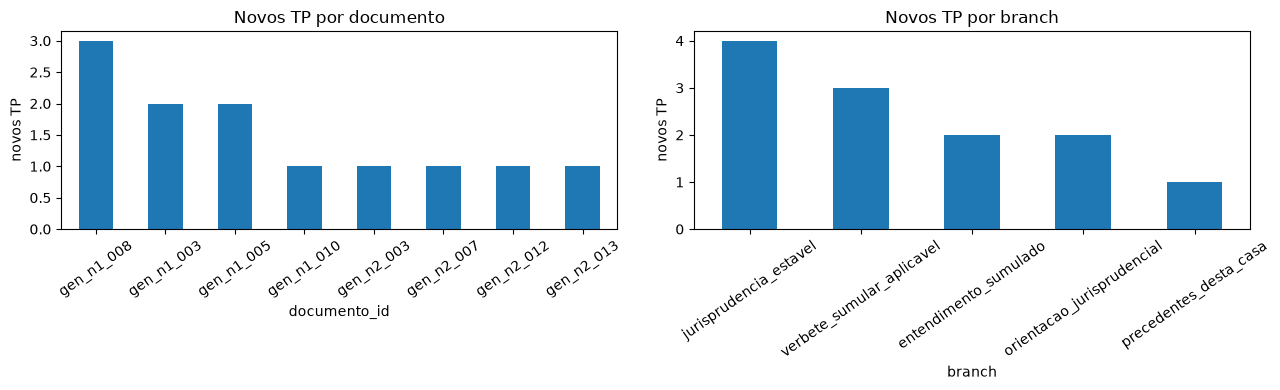

In [3]:
v1_gold, candidate_gold = set(v1_matches.gold_idx), set(candidate_matches.gold_idx)
recovered_ids = sorted(candidate_gold - v1_gold)
assert len(recovered_ids) == 12
recovered_matches = candidate_matches.loc[candidate_matches.gold_idx.isin(recovered_ids)].merge(candidate[['pred_idx', 'text', 'rule']], on='pred_idx').merge(gold[['gold_idx', 'documento_id', 'nivel', 'inicio', 'fim', 'span_text', 'classificacao']], on='gold_idx')
recovered_matches['branch'] = recovered_matches.rule.str.removeprefix('jurisprudencia_geral:')
recovered_matches['exact_or_iou'] = recovered_matches.apply(lambda row: 'exact' if row.exact else f"IoU={row.iou:.3f}", axis=1)

def context(documento_id: str, start: int, end: int, radius: int = 75) -> str:
    text = texts[documento_id]
    return (text[max(0, start-radius):start] + ' <GOLD> ' + text[start:end] + ' </GOLD> ' + text[end:min(len(text), end+radius)]).replace('\n', ' ↵ ')

recovered_matches['context'] = recovered_matches.apply(lambda row: context(row.documento_id, row.inicio, row.fim), axis=1)
display(recovered_matches[['documento_id', 'nivel', 'inicio', 'fim', 'span_text', 'classificacao', 'branch', 'rule', 'exact_or_iou', 'context']].sort_values(['documento_id', 'inicio']))

by_document = recovered_matches.groupby(['documento_id', 'nivel']).size().rename('novos_TP').reset_index().sort_values('novos_TP', ascending=False)
by_document['%_dos_12'] = by_document.novos_TP / len(recovered_matches)
branch_summary = recovered_matches.groupby('branch').agg(TP_recuperados=('gold_idx', 'size'), documentos=('documento_id', 'nunique'), N1=('nivel', lambda value: (value == 'N1').sum()), N2=('nivel', lambda value: (value == 'N2').sum())).reset_index().sort_values('TP_recuperados', ascending=False)
surface_summary = recovered_matches.assign(superficie=recovered_matches.text.str.lower().str.replace(r'\s+', ' ', regex=True).str.strip()).groupby(['branch', 'superficie']).agg(quantidade=('gold_idx', 'size'), documentos=('documento_id', 'nunique')).reset_index().sort_values(['quantidade', 'superficie'], ascending=[False, True])
display(by_document); display(branch_summary); display(surface_summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
by_document.set_index('documento_id')['novos_TP'].plot.bar(ax=axes[0], title='Novos TP por documento', ylabel='novos TP')
branch_summary.set_index('branch')['TP_recuperados'].plot.bar(ax=axes[1], title='Novos TP por branch', ylabel='novos TP')
for axis in axes: axis.tick_params(axis='x', rotation=35)
plt.tight_layout(); plt.show()


## 4. Concentração, N1/N2 e auditoria dos candidatos novos

LOODO abaixo mede apenas concentração/fragilidade: não é estimativa imparcial de leaderboard, porque a regra e todos os documentos já foram observados.

,documentos_beneficiados,top1_share,top2_share,top3_share,HHI
0,8,0.25,0.417,0.583,0.153


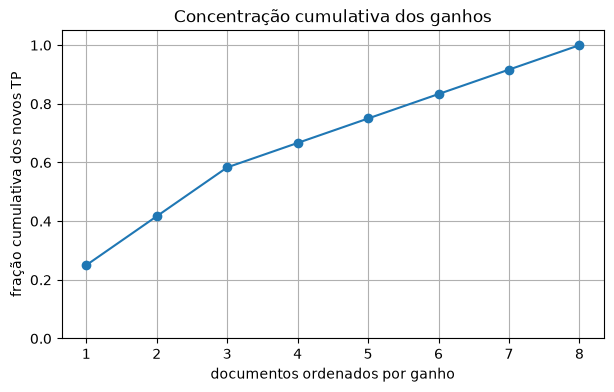

,nivel,novos_TP,documentos_beneficiados
0,N1,8,4
1,N2,4,4


,variant,nivel,TP,FP,FN,precision,recall,F1
0,V1,N1,64,46,52,0.582,0.552,0.566
1,jurisprudencia_geral,N1,72,46,44,0.610,0.621,0.615
2,V1,N2,41,43,68,0.488,0.376,0.425
3,jurisprudencia_geral,N2,45,43,64,0.511,0.413,0.457


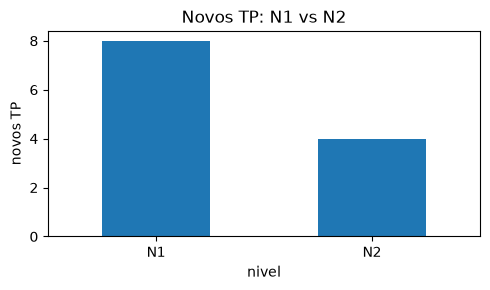

,documento_id,text,rule,matched
20,gen_n1_003,jurisprudência pacífica desta Corte,jurisprudencia_geral:jurisprudencia_estavel,True
24,gen_n1_003,entendimento sumulado sobre a matéria,jurisprudencia_geral:entendimento_sumulado,True
38,gen_n1_005,jurisprudência\npacífica desta Corte,jurisprudencia_geral:jurisprudencia_estavel,True
39,gen_n1_005,precedentes desta Casa,jurisprudencia_geral:precedentes_desta_casa,True
66,gen_n1_008,orientação jurisprudencial,jurisprudencia_geral:orientacao_jurisprudencial,True
73,gen_n1_008,verbete sumular aplicável,jurisprudencia_geral:verbete_sumular_aplicavel,True
74,gen_n1_008,orientação jurisprudencial,jurisprudencia_geral:orientacao_jurisprudencial,True
86,gen_n1_010,jurisprudência\npacífica desta Corte,jurisprudencia_geral:jurisprudencia_estavel,True
132,gen_n2_003,jurisprudência\nconsolidada dos tribunais superiores,jurisprudencia_geral:jurisprudencia_estavel,True
165,gen_n2_007,verbete sumular aplicável,jurisprudencia_geral:verbete_sumular_aplicavel,True


,efeito,documentos
0,sem disparo,18
1,dispara e acerta,8


In [4]:
shares = by_document.novos_TP.sort_values(ascending=False) / len(recovered_matches)
concentration = {'documentos_beneficiados': len(by_document), 'top1_share': shares.head(1).sum(), 'top2_share': shares.head(2).sum(), 'top3_share': shares.head(3).sum(), 'HHI': (shares ** 2).sum()}
display(pd.DataFrame([concentration]).round(3))
shares.cumsum().reset_index(drop=True).plot.marker = None
plt.figure(figsize=(7, 4)); plt.plot(range(1, len(shares)+1), shares.cumsum(), marker='o'); plt.ylim(0, 1.05); plt.xlabel('documentos ordenados por ganho'); plt.ylabel('fração cumulativa dos novos TP'); plt.title('Concentração cumulativa dos ganhos'); plt.grid(True); plt.show()

level_rows = []
for level in ('N1', 'N2'):
    gold_slice = gold.loc[gold.nivel.eq(level)]
    for name, predictions, matches in [('V1', v1, v1_matches), ('jurisprudencia_geral', candidate, candidate_matches)]:
        pred_slice = predictions.loc[predictions.nivel.eq(level)]
        level_rows.append({'nivel': level, **metrics(name, predictions, matches, gold_slice, pred_slice)})
level_metrics = pd.DataFrame(level_rows)
level_gain = recovered_matches.groupby('nivel').agg(novos_TP=('gold_idx', 'size'), documentos_beneficiados=('documento_id', 'nunique')).reset_index()
display(level_gain); display(level_metrics[['variant', 'nivel', 'TP', 'FP', 'FN', 'precision', 'recall', 'F1']].round(3))
level_gain.set_index('nivel')['novos_TP'].plot.bar(figsize=(5, 3), title='Novos TP: N1 vs N2', ylabel='novos TP'); plt.xticks(rotation=0); plt.tight_layout(); plt.show()

v1_keys = set(zip(v1.documento_id, v1.start, v1.end))
new_candidates = candidate.loc[~candidate.apply(lambda row: (row.documento_id, row.start, row.end) in v1_keys, axis=1)].copy()
new_matched = set(candidate_matches.pred_idx)
new_candidates['matched'] = new_candidates.pred_idx.isin(new_matched)
new_fp = new_candidates.loc[~new_candidates.matched]
assert len(new_candidates) == 12 and len(new_fp) == 0
document_effect = pd.DataFrame({'documento_id': sorted(texts)}).merge(by_document[['documento_id', 'novos_TP']], how='left').fillna({'novos_TP': 0})
document_effect['efeito'] = document_effect.novos_TP.map(lambda value: 'dispara e acerta' if value else 'sem disparo')
display(new_candidates[['documento_id', 'text', 'rule', 'matched']]); display(document_effect.efeito.value_counts().rename_axis('efeito').reset_index(name='documentos'))


## 5. LOODO, remoção dos dois documentos principais e ablação interna

A regra é congelada; a única transformação permitida é remover branches já existentes.

,documento_removido,ΔTP,ΔFP,ΔFN,ΔF1
7,gen_n1_008,9,0,-9,0.033171
2,gen_n1_003,10,0,-10,0.036527
4,gen_n1_005,10,0,-10,0.036174
9,gen_n1_010,11,0,-11,0.040414
15,gen_n2_003,11,0,-11,0.039628
25,gen_n2_013,11,0,-11,0.039251
24,gen_n2_012,11,0,-11,0.039690
19,gen_n2_007,11,0,-11,0.039373
6,gen_n1_007,12,0,-12,0.043330
5,gen_n1_006,12,0,-12,0.043835


,min_ΔTP,median_ΔTP,max_ΔTP,min_ΔF1,median_ΔF1,max_ΔF1,ΔTP_positivo,ΔF1_positivo,ΔFP_zero
0,9,12.0,12,0.033,0.043,0.044,26,26,26


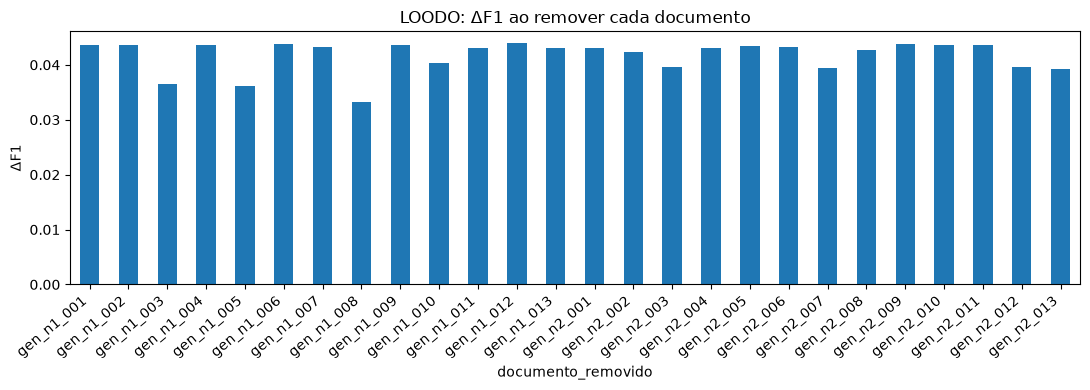

,variant,TP,FP,FN,precision,recall,F1,exact,documentos_removidos
0,V1,94,81,112,0.537,0.456,0.493,17,"gen_n1_008, gen_n1_003"
1,jurisprudencia_geral,101,81,105,0.555,0.490,0.521,21,"gen_n1_008, gen_n1_003"


,variant,TP,FP,FN,F1,exact,novos_TP
0,jurisprudencia_geral,117,89,108,0.543,25,12
1,sem_jurisprudencia_estavel,113,89,112,0.529,21,8
2,sem_orientacao_jurisprudencial,115,89,110,0.536,25,10
3,sem_entendimento_sumulado,115,89,110,0.536,23,10
4,sem_precedentes_desta_casa,116,89,109,0.540,25,11
5,sem_verbete_sumular_aplicavel,114,89,111,0.533,25,9


,variant,TP,FP,FN,precision,recall,F1,exact
0,jurisprudencia_geral,117,89,108,0.568,0.52,0.543,25
1,regra_minima,117,89,108,0.568,0.52,0.543,25


Branches mínimos: ('jurisprudencia_estavel', 'orientacao_jurisprudencial', 'entendimento_sumulado', 'precedentes_desta_casa', 'verbete_sumular_aplicavel')


In [5]:
def restricted_metric(name: str, predictions: pd.DataFrame, matches: pd.DataFrame, excluded: set[str]) -> dict:
    gold_slice = gold.loc[~gold.documento_id.isin(excluded)]
    pred_slice = predictions.loc[~predictions.documento_id.isin(excluded)]
    return metrics(name, predictions, matches, gold_slice, pred_slice)

loodo_rows = []
for document in sorted(texts):
    base = restricted_metric('V1', v1, v1_matches, {document})
    experiment = restricted_metric('jurisprudencia_geral', candidate, candidate_matches, {document})
    loodo_rows.append({'documento_removido': document, 'ΔTP': experiment['TP']-base['TP'], 'ΔFP': experiment['FP']-base['FP'], 'ΔFN': experiment['FN']-base['FN'], 'ΔF1': experiment['F1']-base['F1']})
loodo = pd.DataFrame(loodo_rows)
stability = pd.DataFrame([{'min_ΔTP': loodo['ΔTP'].min(), 'median_ΔTP': loodo['ΔTP'].median(), 'max_ΔTP': loodo['ΔTP'].max(), 'min_ΔF1': loodo['ΔF1'].min(), 'median_ΔF1': loodo['ΔF1'].median(), 'max_ΔF1': loodo['ΔF1'].max(), 'ΔTP_positivo': int((loodo['ΔTP'] > 0).sum()), 'ΔF1_positivo': int((loodo['ΔF1'] > 0).sum()), 'ΔFP_zero': int((loodo['ΔFP'] == 0).sum())}])
display(loodo.sort_values('ΔTP')); display(stability.round(3))
loodo.set_index('documento_removido')['ΔF1'].plot.bar(figsize=(11, 4), title='LOODO: ΔF1 ao remover cada documento', ylabel='ΔF1'); plt.xticks(rotation=40, ha='right'); plt.tight_layout(); plt.show()

top_documents = by_document.documento_id.head(2).tolist()
two_out_base = restricted_metric('V1', v1, v1_matches, set(top_documents))
two_out_candidate = restricted_metric('jurisprudencia_geral', candidate, candidate_matches, set(top_documents))
two_out = pd.DataFrame([two_out_base, two_out_candidate]); two_out['documentos_removidos'] = ', '.join(top_documents)
display(two_out.round(3))

ablation_rows = [candidate_metrics]
for branch in BRANCHES:
    kept = tuple(name for name in BRANCHES if name != branch)
    _, _, result = evaluate(kept, f'sem_{branch}')
    ablation_rows.append(result)
ablation = pd.DataFrame(ablation_rows)
ablation['novos_TP'] = ablation.TP - baseline['TP']
display(ablation[['variant', 'TP', 'FP', 'FN', 'F1', 'exact', 'novos_TP']].round(3))

subset_results = []
for size in range(1, len(BRANCHES)+1):
    for subset in itertools.combinations(BRANCHES, size):
        _, _, result = evaluate(subset, '+'.join(subset))
        result['branches'] = subset
        subset_results.append(result)
subset_results = pd.DataFrame(subset_results)
minimal = subset_results.loc[(subset_results.TP.eq(candidate_metrics['TP'])) & (subset_results.FP.eq(candidate_metrics['FP']))].sort_values(['branches', 'exact'], key=lambda series: series.map(len) if series.name == 'branches' else series, ascending=[True, False]).iloc[0]
minimal_branches = tuple(minimal.branches)
minimal_predictions, minimal_matches, minimal_metrics = evaluate(minimal_branches, 'regra_minima')
display(pd.DataFrame([candidate_metrics, minimal_metrics]).round(3)); print('Branches mínimos:', minimal_branches)


## 6. Complexidade, evidência e limite metodológico

A regra reconhece referências jurisprudenciais gerais por expressões jurídicas estabelecidas — orientação jurisprudencial, entendimento sumulado, precedentes da Corte ou verbete sumular — sem depender de identificador, classe gold ou frequência observada. A estrutura é linguística/jurídica geral; a escolha destas cinco alternativas, porém, foi empírica a partir do gold e precisa da futura confirmação blind. Nenhuma análise aqui substitui o blind set dos organizadores.

In [6]:
complexity = pd.DataFrame([
    {'evidência': 'padrões regex', 'resultado': len(BRANCHES), 'interpretação': 'cinco alternativas semanticamente relacionadas'},
    {'evidência': 'lookarounds / condições negativas', 'resultado': '0 / 0', 'interpretação': 'sem lógica de exceção'},
    {'evidência': 'exceções por documento, ID ou classe', 'resultado': 'não', 'interpretação': 'nenhuma dependência do gold na execução'},
    {'evidência': 'novos TP / novos FP', 'resultado': '12 / 0', 'interpretação': 'cobertura adicional sem ruído nesta amostra'},
    {'evidência': 'documentos beneficiados', 'resultado': concentration['documentos_beneficiados'], 'interpretação': 'mede distribuição documental'},
    {'evidência': 'top-1 / top-3 / HHI', 'resultado': f"{concentration['top1_share']:.3f} / {concentration['top3_share']:.3f} / {concentration['HHI']:.3f}", 'interpretação': 'concentração descritiva, sem threshold mágico'},
    {'evidência': 'LOODO com ΔF1 > 0', 'resultado': f"{int((loodo['ΔF1'] > 0).sum())}/26", 'interpretação': 'o ganho persiste salvo quando se remove toda a cobertura recuperada'},
    {'evidência': 'complexidade qualitativa', 'resultado': 'LOW', 'interpretação': 'branches pequenos, sem lookarounds nem exceções'},
])
display(complexity)
risk = 'LOW GENERALIZATION RISK'
decision = 'A) Promote — implementar a regra em CitationDetector V2 (em tarefa futura)'
print('Classificação de risco:', risk)
print('Decisão analítica:', decision)
print('Atenção metodológica: LOODO mede fragilidade/concentração; não é holdout verdadeiro nem previsão de leaderboard.')
print('SHA-256 depois:', sha256_file(DB_PATH))
print('Baseline V1:', baseline)


,evidência,resultado,interpretação
0,padrões regex,5,cinco alternativas semanticamente relacionadas
1,lookarounds / condições negativas,0 / 0,sem lógica de exceção
2,"exceções por documento, ID ou classe",não,nenhuma dependência do gold na execução
3,novos TP / novos FP,12 / 0,cobertura adicional sem ruído nesta amostra
4,documentos beneficiados,8,mede distribuição documental
5,top-1 / top-3 / HHI,0.250 / 0.583 / 0.153,"concentração descritiva, sem threshold mágico"
6,LOODO com ΔF1 > 0,26/26,o ganho persiste salvo quando se remove toda a cobertura recuperada
7,complexidade qualitativa,LOW,"branches pequenos, sem lookarounds nem exceções"


Classificação de risco: LOW GENERALIZATION RISK
Decisão analítica: A) Promote — implementar a regra em CitationDetector V2 (em tarefa futura)
Atenção metodológica: LOODO mede fragilidade/concentração; não é holdout verdadeiro nem previsão de leaderboard.
SHA-256 depois: d759681be82ee00f383b49a5c76c42dd475564e042272e00730252468dcb6e71
Baseline V1: {'variant': 'V1', 'TP': 105, 'FP': 89, 'FN': 120, 'precision': 0.5412371134020618, 'recall': 0.4666666666666667, 'F1': 0.5011933174224343, 'exact': 19}
